# Complete Code File

## Predicting Weather:

* precipitation
* temperature
* thunder

## Logistic Regression

### Predicting thunder using average wind and precipitation

This model explores the predictability of thunder using precipitation and average wind speed. Our data had thunder as either 1 or NaN, so we decided a logistic regression would best model this concept.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics

Read in the data, prepare for model.

In [2]:
# read in data
weather = pd.read_csv("weatherdataCMSE.csv")

In [3]:
# Make all N/A values 0 to use for model
weather = weather.fillna(0)

# check number of instances with thunder (1)
len(weather[weather["WT03"] == 1])  

38

Create training and testing sets with a smaller data set of thunder, with an equal number of thunder instances as no thunder instances. 

In [4]:
# rows with thunder
thunder = weather[weather["WT03"]==1]

# randomly select rows with no thunder
no_thunder = weather[weather["WT03"]==0]
no_thunder = no_thunder.sample(n=38, random_state=2)  #same number of class 0 as class 1

# combine thunder and no thunder to create sample data set
sample_t = pd.concat([thunder, no_thunder])

Make training and testing vectors and labels for the model using wind and precipitation as the features.

In [9]:
# define thunder column as labels (0 or 1), features as our predictors precipitation and wind
labels = sample_t["WT03"]
features = sample_t[["AWND", "PRCP"]]

train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,labels, test_size=.25, random_state=6)  # random state for consistent results

Create model, adding a constant to the predictors.

In [8]:
# create model
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))

# fit the model
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.505104
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   WT03   No. Observations:                   57
Model:                          Logit   Df Residuals:                       54
Method:                           MLE   Df Model:                            2
Date:                Fri, 21 Nov 2025   Pseudo R-squ.:                  0.2711
Time:                        22:36:38   Log-Likelihood:                -28.791
converged:                       True   LL-Null:                       -39.501
Covariance Type:            nonrobust   LLR p-value:                 2.233e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2725      0.907      1.404      0.160      -0.504       3.049
AWND          -0.2955      0.

Find predicted classification, compare to actual classification for accuracy.

In [11]:
predicted = result.predict()

# manually separate predictions into 0 or 1
y_pred = []
for y in predicted:
    if y > .5:
        y = 1
        y_pred.append(y)
    elif y < .5:
        y = 0
        y_pred.append(y)

In [12]:
# compare the predictions to the actual values
metrics.accuracy_score(train_labels, y_pred)

0.7719298245614035

Plot the training data and decision boundary from the model.

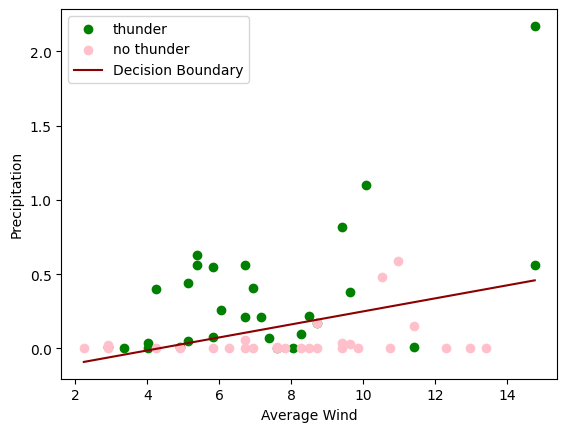

In [16]:
#coefficients
c = result.params.iloc[0]
a1 = result.params.iloc[1]
a2 = result.params.iloc[2]

#x range
x = np.linspace(train_vectors["AWND"].min(), train_vectors["AWND"].max(), 100)

#decision boundary/ classification
# constant + a1(x) + a2(y) = 0
y = (-(c) - (a1*x)) / a2

#scatter plot of data in training vectors, each class plotted separately to label them
plt.scatter(train_vectors["AWND"][train_labels==1], train_vectors["PRCP"][train_labels==1], 
            color="green", label="thunder")
plt.scatter(train_vectors["AWND"][train_labels==0], train_vectors["PRCP"][train_labels==0], 
            color="pink", label="no thunder")
plt.xlabel("Average Wind")
plt.ylabel("Precipitation")
plt.plot(x, line, color='darkred', label="Decision Boundary")
plt.legend()

## Multiple Regression 

In this part of the project, we used multiple regression to explore which variables had significant relationships with different weather outcomes. Instead of only looking at one predictor at a time, multiple regression allowed us to combine several variables and see how they worked together. By testing things like temperature, wind speed, peak gusts, and weather-type indicators, we were able to see which factors actually made a meaningful impact and which ones didn’t. This helped us understand the data better and see how different weather conditions are connected.

### Model 1: Predicting Maximum Temperature Using Wind Speed and Thunder

In [3]:
# Loading the data
df = pd.read_csv("weatherdataCMSE.csv")  

# Selecting variables and dropping missing rows
data = df[['TMAX', 'AWND', 'WT03']].dropna()

# Defining X and y
X = data[['AWND', 'WT03']]   # independent variables
y = data['TMAX']             # dependent variable

# Adding constant term for OLS intercept
X = sm.add_constant(X)

# Fitting the OLS model
model = sm.OLS(y, X).fit()

# Displaying the full statistical report
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   TMAX   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     34.67
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           9.80e-07
Time:                        19:38:30   Log-Likelihood:                -133.97
No. Observations:                  38   AIC:                             271.9
Df Residuals:                      36   BIC:                             275.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AWND          -2.6977      0.458     -5.888      0.0

### Model 2: Predicting Precipitation Using Wind Speed and Thunder

In [4]:
# Loading the data
df = pd.read_csv("weatherdataCMSE.csv")  

# Selecting variables and dropping missing rows
data = df[['PRCP', 'AWND', 'WT03']].dropna()

# Define X and y
X = data[['AWND', 'WT03']]   # independent variables
y = data['PRCP']             # dependent variable

# Adding constant term for OLS intercept
X = sm.add_constant(X)

# Fitting the OLS model
model = sm.OLS(y, X).fit()

# Displaying the full statistical report
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   PRCP   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     14.96
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           0.000442
Time:                        19:39:44   Log-Likelihood:                -13.497
No. Observations:                  38   AIC:                             30.99
Df Residuals:                      36   BIC:                             34.27
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AWND           0.0744      0.019      3.868      0.0